converted the jsonl file to csv files 

In [12]:
import sys

!{sys.executable} -m pip install --force-reinstall --no-cache-dir \
    "numpy==1.26.4" \
    "pandas==2.1.4" \
    "scipy==1.11.4" \
    "scikit-learn==1.3.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 11.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 11.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 11.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 12.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.5
    Uninstalling pytz-2026.5:
      Successfully uninstalled pytz-2026.5
  Att

In [1]:
import json
import csv
import os

# ============================================================
# ASK FOR JSONL FILE
# ============================================================

jsonl_file = "setting.jsonl"

# ============================================================
# CREATE DATA FOLDER
# ============================================================

os.makedirs("data", exist_ok=True)

# ============================================================
# OUTPUT FILE
# ============================================================

base_name = os.path.splitext(
    os.path.basename(jsonl_file)
)[0]

csv_file = os.path.join(
    "data",
    base_name + ".csv"
)

# ============================================================
# READ JSONL
# ============================================================

rows = []

with open(jsonl_file, "r", encoding="utf-8") as file:

    for line in file:

        line = line.strip()

        if not line:
            continue

        data = json.loads(line)

        row = {
            "server_timestamp": data.get("server_timestamp"),
            "device_id": data.get("device_id"),
            "window_id": data.get("window_id"),
            "sample_rate": data.get("sample_rate"),
            "window_duration_ms": data.get("window_duration_ms")
        }

        # ----------------------------------------------------
        # Add 100 samples
        # ----------------------------------------------------

        samples = data.get("samples", [])

        for i, sample in enumerate(samples, start=1):

            row[f"s{i}_timestamp"] = sample.get(
                "timestamp_ms"
            )

            row[f"s{i}_ax"] = sample.get("ax")
            row[f"s{i}_ay"] = sample.get("ay")
            row[f"s{i}_az"] = sample.get("az")

            row[f"s{i}_gx"] = sample.get("gx")
            row[f"s{i}_gy"] = sample.get("gy")
            row[f"s{i}_gz"] = sample.get("gz")

        rows.append(row)

# ============================================================
# WRITE CSV
# ============================================================

if rows:

    fieldnames = rows[0].keys()

    with open(
        csv_file,
        "w",
        newline="",
        encoding="utf-8"
    ) as file:

        writer = csv.DictWriter(
            file,
            fieldnames=fieldnames
        )

        writer.writeheader()
        writer.writerows(rows)

    print()
    print("Conversion successful!")
    print("Input :", jsonl_file)
    print("Output:", csv_file)
    print("Rows  :", len(rows))

else:

    print("No data found in JSONL file.")


Conversion successful!
Input : setting.jsonl
Output: data/setting.csv
Rows  : 3038


In [2]:
import json
import csv
import os

# ============================================================
# ASK FOR JSONL FILE
# ============================================================

jsonl_file = "walking.jsonl"

# ============================================================
# CREATE DATA FOLDER
# ============================================================

os.makedirs("data", exist_ok=True)

# ============================================================
# OUTPUT FILE
# ============================================================

base_name = os.path.splitext(
    os.path.basename(jsonl_file)
)[0]

csv_file = os.path.join(
    "data",
    base_name + ".csv"
)

# ============================================================
# READ JSONL
# ============================================================

rows = []

with open(jsonl_file, "r", encoding="utf-8") as file:

    for line in file:

        line = line.strip()

        if not line:
            continue

        data = json.loads(line)

        row = {
            "server_timestamp": data.get("server_timestamp"),
            "device_id": data.get("device_id"),
            "window_id": data.get("window_id"),
            "sample_rate": data.get("sample_rate"),
            "window_duration_ms": data.get("window_duration_ms")
        }

        # ----------------------------------------------------
        # Add 100 samples
        # ----------------------------------------------------

        samples = data.get("samples", [])

        for i, sample in enumerate(samples, start=1):

            row[f"s{i}_timestamp"] = sample.get(
                "timestamp_ms"
            )

            row[f"s{i}_ax"] = sample.get("ax")
            row[f"s{i}_ay"] = sample.get("ay")
            row[f"s{i}_az"] = sample.get("az")

            row[f"s{i}_gx"] = sample.get("gx")
            row[f"s{i}_gy"] = sample.get("gy")
            row[f"s{i}_gz"] = sample.get("gz")

        rows.append(row)

# ============================================================
# WRITE CSV
# ============================================================

if rows:

    fieldnames = rows[0].keys()

    with open(
        csv_file,
        "w",
        newline="",
        encoding="utf-8"
    ) as file:

        writer = csv.DictWriter(
            file,
            fieldnames=fieldnames
        )

        writer.writeheader()
        writer.writerows(rows)

    print()
    print("Conversion successful!")
    print("Input :", jsonl_file)
    print("Output:", csv_file)
    print("Rows  :", len(rows))

else:

    print("No data found in JSONL file.")


Conversion successful!
Input : walking.jsonl
Output: data/walking.csv
Rows  : 1323


In [3]:
import json
import csv
import os

# ============================================================
# ASK FOR JSONL FILE
# ============================================================

jsonl_file = "running.jsonl"

# ============================================================
# CREATE DATA FOLDER
# ============================================================

os.makedirs("data", exist_ok=True)

# ============================================================
# OUTPUT FILE
# ============================================================

base_name = os.path.splitext(
    os.path.basename(jsonl_file)
)[0]

csv_file = os.path.join(
    "data",
    base_name + ".csv"
)

# ============================================================
# READ JSONL
# ============================================================

rows = []

with open(jsonl_file, "r", encoding="utf-8") as file:

    for line in file:

        line = line.strip()

        if not line:
            continue

        data = json.loads(line)

        row = {
            "server_timestamp": data.get("server_timestamp"),
            "device_id": data.get("device_id"),
            "window_id": data.get("window_id"),
            "sample_rate": data.get("sample_rate"),
            "window_duration_ms": data.get("window_duration_ms")
        }

        # ----------------------------------------------------
        # Add 100 samples
        # ----------------------------------------------------

        samples = data.get("samples", [])

        for i, sample in enumerate(samples, start=1):

            row[f"s{i}_timestamp"] = sample.get(
                "timestamp_ms"
            )

            row[f"s{i}_ax"] = sample.get("ax")
            row[f"s{i}_ay"] = sample.get("ay")
            row[f"s{i}_az"] = sample.get("az")

            row[f"s{i}_gx"] = sample.get("gx")
            row[f"s{i}_gy"] = sample.get("gy")
            row[f"s{i}_gz"] = sample.get("gz")

        rows.append(row)

# ============================================================
# WRITE CSV
# ============================================================

if rows:

    fieldnames = rows[0].keys()

    with open(
        csv_file,
        "w",
        newline="",
        encoding="utf-8"
    ) as file:

        writer = csv.DictWriter(
            file,
            fieldnames=fieldnames
        )

        writer.writeheader()
        writer.writerows(rows)

    print()
    print("Conversion successful!")
    print("Input :", jsonl_file)
    print("Output:", csv_file)
    print("Rows  :", len(rows))

else:

    print("No data found in JSONL file.")


Conversion successful!
Input : running.jsonl
Output: data/running.csv
Rows  : 2323


now add the output value to csv file 
output for the 
setting =0
walking = 1
running = 2


In [8]:
import pandas as pd

# ============================================================
# FILE
# ============================================================

file = "data/setting.csv"

# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(file)

# ============================================================
# ADD OUTPUT COLUMN
# ============================================================

df["output"] = 0

# ============================================================
# SAVE BACK TO SAME FILE
# ============================================================

df.to_csv(
    file,
    index=False
)

print("Done!")
print("File:", file)
print("Rows:", len(df))
print("Added column: output = 0")

Done!
File: data/setting.csv
Rows: 3038
Added column: output = 0


In [9]:
import pandas as pd

# ============================================================
# FILE
# ============================================================

file = "data/walking.csv"

# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(file)

# ============================================================
# ADD OUTPUT COLUMN
# ============================================================

df["output"] = 1

# ============================================================
# SAVE BACK TO SAME FILE
# ============================================================

df.to_csv(
    file,
    index=False
)

print("Done!")
print("File:", file)
print("Rows:", len(df))
print("Added column: output = 1")

Done!
File: data/walking.csv
Rows: 1323
Added column: output = 1


In [10]:
import pandas as pd

# ============================================================
# FILE
# ============================================================

file = "data/running.csv"

# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(file)

# ============================================================
# ADD OUTPUT COLUMN
# ============================================================

df["output"] = 2

# ============================================================
# SAVE BACK TO SAME FILE
# ============================================================

df.to_csv(
    file,
    index=False
)

print("Done!")
print("File:", file)
print("Rows:", len(df))
print("Added column: output = 2")

Done!
File: data/running.csv
Rows: 2323
Added column: output = 2


now we will merge the all csv file with output values


In [23]:
import pandas as pd

# ============================================================
# INPUT FILES
# ============================================================

file1 = "data/setting.csv"
file2 = "data/walking.csv"
file3 = "data/running.csv"

# ============================================================
# READ FILES
# ============================================================

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)

# ============================================================
# MERGE
# ============================================================

df = pd.concat(
    [df1, df2, df3],
    ignore_index=True
)

# ============================================================
# SAVE
# ============================================================

output_file = "data/y.csv"

df.to_csv(
    output_file,
    index=False
)

# ============================================================
# INFORMATION
# ============================================================

print("Done!")
print()
print("Files merged:")
print(file1)
print(file2)
print(file3)

print()
print("Output:", output_file)
print("Total rows:", len(df))
print("Total columns:", len(df.columns))

Done!

Files merged:
data/setting.csv
data/walking.csv
data/running.csv

Output: data/y.csv
Total rows: 6684
Total columns: 706


Shape: (6684, 701)

Class distribution:
output
0    3038
1    1323
2    2323
Name: count, dtype: int64


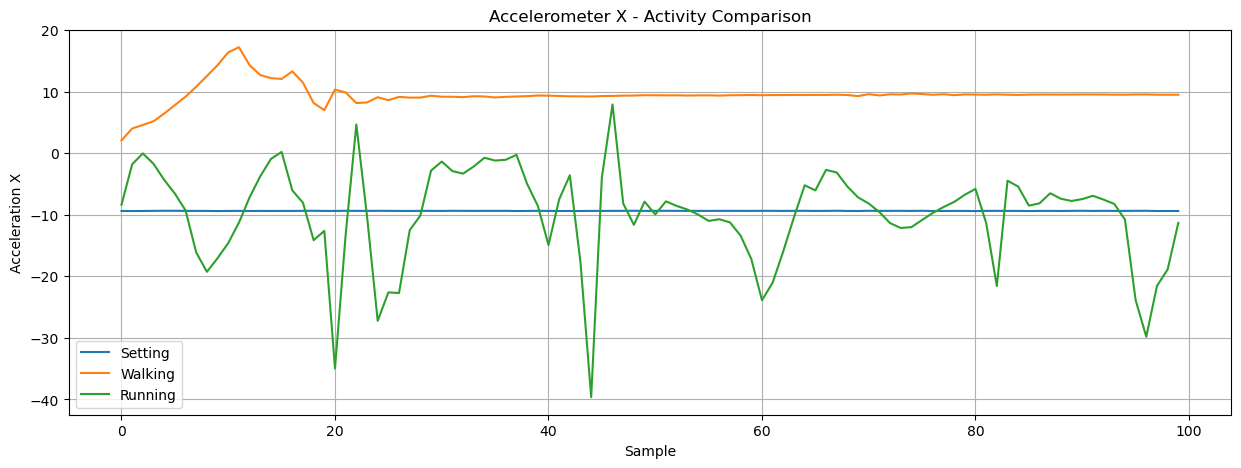

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/y.csv")

print("Shape:", df.shape)

print("\nClass distribution:")
print(df["output"].value_counts().sort_index())

# ============================================================
# PICK ONE WINDOW FROM EACH CLASS
# ============================================================

setting = df[df["output"] == 0].iloc[0]
walking = df[df["output"] == 1].iloc[0]
running = df[df["output"] == 2].iloc[0]


# ============================================================
# FUNCTION TO EXTRACT ACCELEROMETER DATA
# ============================================================

def get_acceleration(row):

    ax = [
        row[f"s{i}_ax"]
        for i in range(1, 101)
    ]

    ay = [
        row[f"s{i}_ay"]
        for i in range(1, 101)
    ]

    az = [
        row[f"s{i}_az"]
        for i in range(1, 101)
    ]

    return np.array(ax), np.array(ay), np.array(az)


# ============================================================
# EXTRACT
# ============================================================

setting_ax, setting_ay, setting_az = \
    get_acceleration(setting)

walking_ax, walking_ay, walking_az = \
    get_acceleration(walking)

running_ax, running_ay, running_az = \
    get_acceleration(running)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(setting_ax, label="Setting")
plt.plot(walking_ax, label="Walking")
plt.plot(running_ax, label="Running")

plt.xlabel("Sample")
plt.ylabel("Acceleration X")
plt.title("Accelerometer X - Activity Comparison")

plt.legend()
plt.grid()

plt.show()

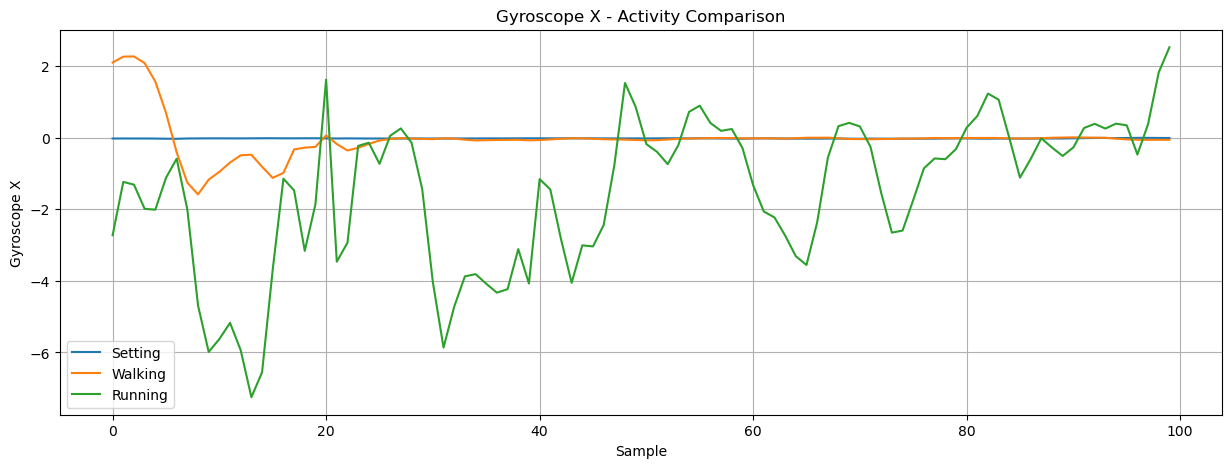

In [47]:
def get_gyro(row):

    gx = [
        row[f"s{i}_gx"]
        for i in range(1, 101)
    ]

    gy = [
        row[f"s{i}_gy"]
        for i in range(1, 101)
    ]

    gz = [
        row[f"s{i}_gz"]
        for i in range(1, 101)
    ]

    return np.array(gx), np.array(gy), np.array(gz)


setting_gx, setting_gy, setting_gz = get_gyro(setting)
walking_gx, walking_gy, walking_gz = get_gyro(walking)
running_gx, running_gy, running_gz = get_gyro(running)


plt.figure(figsize=(15, 5))

plt.plot(setting_gx, label="Setting")
plt.plot(walking_gx, label="Walking")
plt.plot(running_gx, label="Running")

plt.xlabel("Sample")
plt.ylabel("Gyroscope X")
plt.title("Gyroscope X - Activity Comparison")

plt.legend()
plt.grid()

plt.show()

now we going to clean the data set 



In [24]:
import pandas as pd

# File
file = "data/y.csv"

# Read CSV
df = pd.read_csv(file)

# Display first 5 rows
print(df.head())


           server_timestamp     device_id  window_id  sample_rate  \
0  2026-10-05T09:29:55.955Z  esp32-c3-009         24           50   
1  2026-10-05T09:29:55.973Z  esp32-c3-010          0           50   
2  2026-10-05T09:29:56.089Z  esp32-c3-011         25           50   
3  2026-10-05T09:29:56.286Z  esp32-c3-007         24           50   
4  2026-10-05T09:29:56.291Z  esp32-c3-001         22           50   

   window_duration_ms  s1_timestamp      s1_ax     s1_ay     s1_az     s1_gx  \
0                2000        186123  -9.385271 -0.792481  2.068590 -0.019185   
1                2000         59445  10.156203 -0.260968  0.756568 -0.007194   
2                2000        161991  -9.311050  0.459687 -0.972046  0.087400   
3                2000        191417  -5.683835  1.556231 -8.633492 -0.013856   
4                2000        143599  -9.679757  0.323217  1.584962  0.028245   

   ...    s99_gy    s99_gz  s100_timestamp    s100_ax   s100_ay   s100_az  \
0  ... -0.001865 -0.026913 

In [26]:
import pandas as pd

# File
file = "data/y.csv"

# Read CSV
df = pd.read_csv(file)

# Columns to remove
columns_to_remove = [
    "server_timestamp",
    "device_id",
    "window_id",
    "sample_rate",
    "window_duration_ms"
]

# Remove columns
df = df.drop(
    columns=columns_to_remove,
    errors="ignore"
)

# Save back to same file
df.to_csv(
    file,
    index=False
)

print("Done!")
print("Removed columns:", columns_to_remove)
print("Remaining rows:", len(df))
print("Remaining columns:", len(df.columns))

Done!
Removed columns: ['server_timestamp', 'device_id', 'window_id', 'sample_rate', 'window_duration_ms']
Remaining rows: 6684
Remaining columns: 701


In [27]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

file = "data/y.csv"

df = pd.read_csv(file)

print("Dataset shape:", df.shape)
print(df["output"].value_counts().sort_index())

Dataset shape: (6684, 701)
output
0    3038
1    1323
2    2323
Name: count, dtype: int64


In [29]:



# ============================================================
# CREATE X
# ============================================================

X = []
y = []

for _, row in df.iterrows():

    window = []

    for i in range(1, 101):

        sample = [
            row[f"s{i}_ax"],
            row[f"s{i}_ay"],
            row[f"s{i}_az"],
            row[f"s{i}_gx"],
            row[f"s{i}_gy"],
            row[f"s{i}_gz"]
        ]

        window.append(sample)

    X.append(window)
    y.append(row["output"])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6684, 100, 6)
y shape: (6684,)


In [36]:
print("Setting :", np.sum(y == 0))
print("Walking :", np.sum(y == 1))
print("Running :", np.sum(y == 2))

Setting : 3038
Walking : 1323
Running : 2323


In [37]:
print("Setting :", np.sum(y == 0))
print("Walking :", np.sum(y == 1))
print("Running :", np.sum(y == 2))

Setting : 3038
Walking : 1323
Running : 2323


Step 4 — Train/test split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5347, 100, 6)
Testing : (1337, 100, 6)


Step 5 — Normalize the sensor data

In [39]:
from sklearn.preprocessing import StandardScaler

# Flatten only for fitting scaler
X_train_flat = X_train.reshape(
    -1,
    X_train.shape[-1]
)

X_test_flat = X_test.reshape(
    -1,
    X_test.shape[-1]
)

scaler = StandardScaler()

X_train_flat = scaler.fit_transform(
    X_train_flat
)

X_test_flat = scaler.transform(
    X_test_flat
)

# Convert back to sequence format
X_train = X_train_flat.reshape(
    X_train.shape
)

X_test = X_test_flat.reshape(
    X_test.shape
)

print("Normalized shape:", X_train.shape)

Normalized shape: (5347, 100, 6)


Step 6 — First ML model: 1D CNN

In [40]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling1D,
    Dense
)

model = Sequential([

    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        input_shape=(100, 6)
    ),

    BatchNormalization(),

    MaxPooling1D(
        pool_size=2
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling1D(
        pool_size=2
    ),

    Conv1D(
        filters=256,
        kernel_size=3,
        activation="relu"
    ),

    GlobalAveragePooling1D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        3,
        activation="softmax"
    )
])

model.summary()

I0000 00:00:1791224048.601455    4084 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791224048.656729    4084 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791224050.088551    4084 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/opt/conda/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 96, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 44, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,683 (686.26 KB)

 Trainable params: 175,299 (684.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [41]:
Dense(3, activation="softmax")

<Dense name=dense_2, built=False>

In [42]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history = model.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    verbose=1
)

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9472 - loss: 0.1537 - val_accuracy: 0.9047 - val_loss: 0.2638
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9773 - loss: 0.0800 - val_accuracy: 0.9654 - val_loss: 0.0991
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9848 - loss: 0.0582 - val_accuracy: 0.9748 - val_loss: 0.1040
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9869 - loss: 0.0559 - val_accuracy: 0.9832 - val_loss: 0.0695
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9899 - loss: 0.0438 - val_accuracy: 0.9738 - val_loss: 0.1004
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9871 - loss: 0.0429 - val_accuracy: 0.9879 - val_loss: 0.0523
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9911 - loss: 0.0379 - val_accuracy: 0.9850 - val_loss: 0.0667
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9881 - loss: 0.0466 - val_accu

In [44]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Test accuracy: {test_accuracy * 100:.2f}%"
)

Test accuracy: 99.03%


In [45]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

y_probability = model.predict(
    X_test
)

y_prediction = np.argmax(
    y_probability,
    axis=1
)

print(
    classification_report(
        y_test,
        y_prediction,
        target_names=[
            "setting",
            "walking",
            "running"
        ]
    )
)

cm = confusion_matrix(
    y_test,
    y_prediction
)

print("Confusion Matrix:")
print(cm)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

     setting       0.99      1.00      0.99       608
     walking       0.99      0.96      0.98       264
     running       1.00      1.00      1.00       465

    accuracy                           0.99      1337
   macro avg       0.99      0.99      0.99      1337
weighted avg       0.99      0.99      0.99      1337

Confusion Matrix:
[[607   1   0]
 [  8 254   2]
 [  0   2 463]]


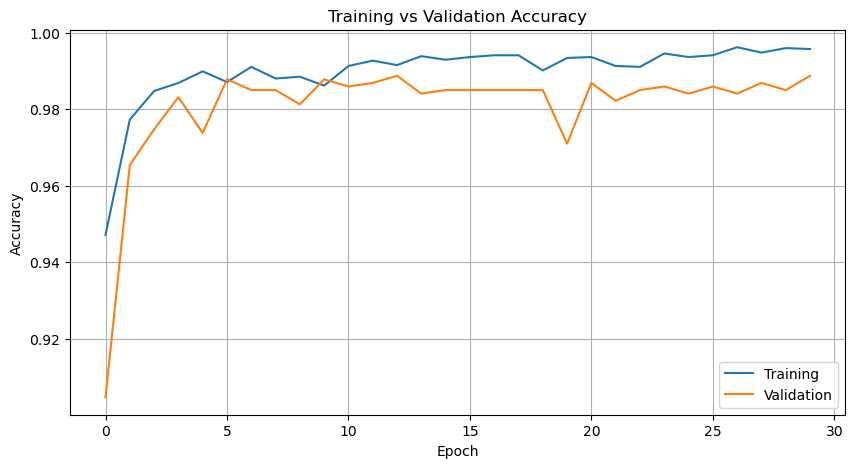

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

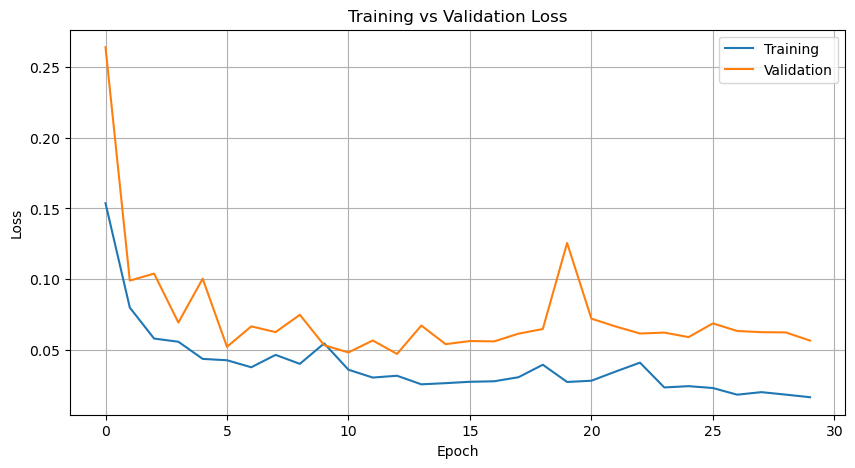

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()




save the trained cnn

In [50]:
model.save("data/activity_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [51]:
import joblib

joblib.dump(scaler, "data/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [56]:
labels = {
    0: "walking",
    1: "running",
    2: "sitting"
}


1. Convert .keras → .tflite

In [58]:
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model("data/activity_model.keras")

# Create TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Convert
tflite_model = converter.convert()

# Save
with open("data/activity_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model created successfully!")

INFO:tensorflow:Assets written to: /tmp/tmpkqjf743_/assets


INFO:tensorflow:Assets written to: /tmp/tmpkqjf743_/assets


Saved artifact at '/tmp/tmpkqjf743_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133794138689360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786892035152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493974864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493975248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493968528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493975440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493968336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493975632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493974672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493973520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493973712: Ten

W0000 00:00:1791224851.246402    4084 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791224851.246423    4084 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


TFLite model created successfully!


I0000 00:00:1791224851.246596    4084 reader.cc:83] Reading SavedModel from: /tmp/tmpkqjf743_
I0000 00:00:1791224851.247665    4084 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1791224851.247682    4084 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpkqjf743_
I0000 00:00:1791224851.257672    4084 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1791224851.319292    4084 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpkqjf743_
I0000 00:00:1791224851.338614    4084 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 92026 microseconds.


In [59]:
import os

size_kb = os.path.getsize("data/activity_model.tflite") / 1024

print(f"Model size: {size_kb:.2f} KB")

Model size: 694.42 KB


In [60]:
import numpy as np
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="data/activity_model.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:")
print(input_details)

print("\nOutput:")
print(output_details)

Input:
[{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([  1, 100,   6], dtype=int32), 'shape_signature': array([ -1, 100,   6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]

Output:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 44, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


/opt/conda/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [62]:
import numpy as np
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="data/activity_model.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("========== INPUT ==========")
print("Shape :", input_details[0]["shape"])
print("Type  :", input_details[0]["dtype"])
print("Index :", input_details[0]["index"])

print("\n========== OUTPUT ==========")
print("Shape :", output_details[0]["shape"])
print("Type  :", output_details[0]["dtype"])
print("Index :", output_details[0]["index"])

========== INPUT ==========
Shape : [  1 100   6]
Type  : <class 'numpy.float32'>
Index : 0

========== OUTPUT ==========
Shape : [1 3]
Type  : <class 'numpy.float32'>
Index : 44


In [63]:
sample = X_test[0:1].astype(np.float32)

interpreter.set_tensor(
    input_details[0]["index"],
    sample
)

interpreter.invoke()

prediction = interpreter.get_tensor(
    output_details[0]["index"]
)

labels = ["Setting", "Walking", "Running"]

predicted_class = np.argmax(prediction[0])

print("Probabilities:", prediction[0])
print("Predicted:", labels[predicted_class])
print("Actual:", labels[y_test[0]])

Probabilities: [1.0000000e+00 4.7427080e-11 1.0209752e-10]
Predicted: Setting
Actual: Setting


Next: INT8 Quantization 🚀

In [64]:
import tensorflow as tf
import numpy as np

def representative_dataset():
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

In [65]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()

with open("data/activity_model_int8.tflite", "wb") as f:
    f.write(tflite_int8_model)

print("INT8 model created successfully!")

INFO:tensorflow:Assets written to: /tmp/tmpxp9trzpt/assets


INFO:tensorflow:Assets written to: /tmp/tmpxp9trzpt/assets


Saved artifact at '/tmp/tmpxp9trzpt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133794138689360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786892035152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493974864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493975248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493968528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493975440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493968336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493975632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493974672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493973520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133786493973712: Ten

/opt/conda/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1791225044.923160    4084 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791225044.923180    4084 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1791225044.923348    4084 reader.cc:83] Reading SavedModel from: /tmp/tmpxp9trzpt
I0000 00:00:1791225044.924569    4084 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1791225044.924579    4084 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpxp9trzpt
I0000 00:00:1791225044.933012    4084 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1791225044.992576    4084 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpxp9trzpt
I0000 00:00:1791225045.010062    4084 loader.cc:471] SavedModel load for tags { serve }; Statu

INT8 model created successfully!


In [66]:
import os

float_size = os.path.getsize(
    "data/activity_model.tflite"
) / 1024

int8_size = os.path.getsize(
    "data/activity_model_int8.tflite"
) / 1024

print(f"Float32 model : {float_size:.2f} KB")
print(f"INT8 model    : {int8_size:.2f} KB")
print(f"Reduction     : {(1 - int8_size / float_size) * 100:.2f}%")

Float32 model : 694.42 KB
INT8 model    : 197.33 KB
Reduction     : 71.58%


In [ ]:
interpreter_int8 = tf.lite.Interpreter(
    model_path="data/activity_model_int8.tflite"
)

interpreter_int8.allocate_tensors()

input_details_int8 = interpreter_int8.get_input_details()
output_details_int8 = interpreter_int8.get_output_details()

print("========== INT8 INPUT ==========")

print("Shape:")
print(input_details_int8[0]["shape"])

print("Type:")
print(input_details_int8[0]["dtype"])

print("Quantization:")
print(input_details_int8[0]["quantization"])

print("\n========== INT8 OUTPUT ==========")

print("Shape:")
print(output_details_int8[0]["shape"])

print("Type:")
print(output_details_int8[0]["dtype"])

print("Quantization:")
print(output_details_int8[0]["quantization"])

    Test INT8 prediction

In [69]:
sample = X_test[0:1].astype(np.float32)

input_scale, input_zero_point = input_details_int8[0]["quantization"]

sample_int8 = np.round(
    sample / input_scale + input_zero_point
).astype(np.int8)

interpreter_int8.set_tensor(
    input_details_int8[0]["index"],
    sample_int8
)

interpreter_int8.invoke()

output_int8 = interpreter_int8.get_tensor(
    output_details_int8[0]["index"]
)

print("INT8 output:", output_int8)

INT8 output: [[ 127 -128 -128]]


Convert the output back to floating-point probabilities:

In [70]:
output_scale, output_zero_point = output_details_int8[0]["quantization"]

output_float = (
    output_int8.astype(np.float32) - output_zero_point
) * output_scale

print("Output probabilities:", output_float)

labels = ["Setting", "Walking", "Running"]

predicted_class = np.argmax(output_float[0])

print("Predicted:", labels[predicted_class])
print("Actual:", labels[y_test[0]])

Output probabilities: [[0.99609375 0.         0.        ]]
Predicted: Setting
Actual: Setting


INT8 MODEL ACCURACY: 99.03%

CLASSIFICATION REPORT

              precision    recall  f1-score   support

     Setting     0.9870    0.9984    0.9926       608
     Walking     0.9883    0.9621    0.9750       264
     Running     0.9957    0.9957    0.9957       465

    accuracy                         0.9903      1337
   macro avg     0.9903    0.9854    0.9878      1337
weighted avg     0.9903    0.9903    0.9902      1337


CONFUSION MATRIX

[[607   1   0]
 [  8 254   2]
 [  0   2 463]]


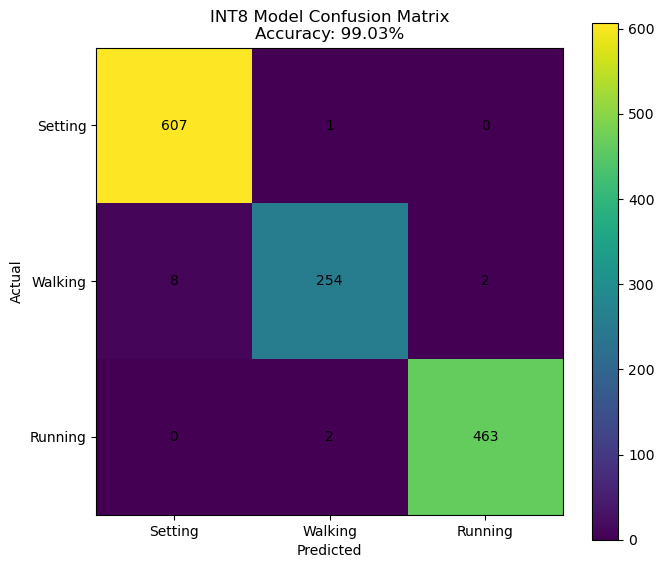

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

labels = ["Setting", "Walking", "Running"]

# --------------------------------------------------
# 1. Run INT8 model on entire test dataset
# --------------------------------------------------

y_pred = []

input_scale, input_zero_point = input_details_int8[0]["quantization"]
output_scale, output_zero_point = output_details_int8[0]["quantization"]

for i in range(len(X_test)):

    # Get one test window
    sample = X_test[i:i+1].astype(np.float32)

    # Float32 -> INT8
    sample_int8 = np.round(
        sample / input_scale + input_zero_point
    ).clip(-128, 127).astype(np.int8)

    # Input
    interpreter_int8.set_tensor(
        input_details_int8[0]["index"],
        sample_int8
    )

    # Inference
    interpreter_int8.invoke()

    # Get INT8 output
    output_int8 = interpreter_int8.get_tensor(
        output_details_int8[0]["index"]
    )

    # INT8 -> float
    output_float = (
        output_int8.astype(np.float32) - output_zero_point
    ) * output_scale

    # Select class with highest probability
    predicted_class = np.argmax(output_float[0])

    y_pred.append(predicted_class)

y_pred = np.array(y_pred)

# --------------------------------------------------
# 2. Accuracy
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"INT8 MODEL ACCURACY: {accuracy * 100:.2f}%")
print("=" * 50)

# --------------------------------------------------
# 3. Classification Report
# --------------------------------------------------

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=labels,
        digits=4
    )
)

# --------------------------------------------------
# 4. Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX\n")
print(cm)

# --------------------------------------------------
# 5. Plot Confusion Matrix
# --------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1, 2],
    labels
)

plt.yticks(
    [0, 1, 2],
    labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"INT8 Model Confusion Matrix\nAccuracy: {accuracy * 100:.2f}%"
)

# Add numbers inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

Jupyter
   ↓
activity_model_int8.tflite
   ↓
convert to C array
   ↓
Arduino IDE
   ↓
ESP32-C3
   ↓
MPU6050
   ↓
real-time Setting / Walking / Running

In [73]:
import tensorflow as tf
import os

MODEL_PATH = "data/activity_model_int8.tflite"

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT")
print("Shape:", input_details[0]["shape"])
print("Type:", input_details[0]["dtype"])
print("Quantization:", input_details[0]["quantization"])

print("\nOUTPUT")
print("Shape:", output_details[0]["shape"])
print("Type:", output_details[0]["dtype"])
print("Quantization:", output_details[0]["quantization"])

size_kb = os.path.getsize(MODEL_PATH) / 1024
print("\nModel size:", round(size_kb, 2), "KB")

INPUT
Shape: [  1 100   6]
Type: <class 'numpy.int8'>
Quantization: (0.10053744167089462, 0)

OUTPUT
Shape: [1 3]
Type: <class 'numpy.int8'>
Quantization: (0.00390625, -128)

Model size: 197.33 KB


/opt/conda/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Step 2 — Generate the C array

In [76]:
from pathlib import Path

model_path = Path("data/activity_model_int8.tflite")
output_path = Path("data/model_data.cc")

model_bytes = model_path.read_bytes()

with open(output_path, "w") as f:
    f.write("#include <stdint.h>\n\n")
    f.write("alignas(16) const unsigned char activity_model[] = {\n")

    for i in range(0, len(model_bytes), 12):
        chunk = model_bytes[i:i+12]
        values = ", ".join(f"0x{b:02x}" for b in chunk)
        f.write("  " + values + ",\n")

    f.write("};\n\n")
    f.write(f"const unsigned int activity_model_len = {len(model_bytes)};\n")

print("Created:", output_path)
print("Model bytes:", len(model_bytes))

Created: data/model_data.cc
Model bytes: 202064


Step 3 — Create a header file

In [77]:
header_path = Path("data/model_data.h")

with open(header_path, "w") as f:
    f.write("#ifndef MODEL_DATA_H\n")
    f.write("#define MODEL_DATA_H\n\n")
    f.write("#include <stdint.h>\n\n")
    f.write("extern const unsigned char activity_model[];\n")
    f.write("extern const unsigned int activity_model_len;\n\n")
    f.write("#endif\n")

print("Created:", header_path)

Created: data/model_data.h


Step 4 — Very important: save the scaler parameters

raw MPU6050
     ↓
StandardScaler
     ↓
CNN

In [81]:
import joblib
import numpy as np

scaler = joblib.load("data/scaler.pkl")

print("Mean:")
print(scaler.mean_)

print("\nScale:")
print(scaler.scale_)

Mean:
[-2.63125544e+00  1.59487935e-01 -5.85830331e-01 -8.15397784e-02
  1.51617742e-02 -2.41204041e-03]

Scale:
[10.90261922  6.11348215  6.14226939  1.65329316  1.62377331  1.50597735]


In [82]:
with open("data/scaler_params.h", "w") as f:

    f.write("#ifndef SCALER_PARAMS_H\n")
    f.write("#define SCALER_PARAMS_H\n\n")

    f.write("const float scaler_mean[6] = {\n")

    for value in scaler.mean_:
        f.write(f"    {value:.10f}f,\n")

    f.write("};\n\n")

    f.write("const float scaler_scale[6] = {\n")

    for value in scaler.scale_:
        f.write(f"    {value:.10f}f,\n")

    f.write("};\n\n")

    f.write("#endif\n")

print("Created data/scaler_params.h")

Created data/scaler_params.h
